In [ ]:
!pip install -q segment-anything
!pip install -q segmentation-models-pytorch
!pip install -q pycocotools
!pip install -q albumentations
!pip install -q supervision
!pip install -q roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 133.9 MB/s eta 0:00:00


In [ ]:
!pip install -q segment-anything
!pip install -q segmentation-models-pytorch
!pip install -q pycocotools
!pip install -q roboflow

In [ ]:
import os, cv2, random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import segmentation_models_pytorch as smp
from segment_anything import sam_model_registry, SamPredictor
from segment_anything.utils.transforms import ResizeLongestSide
from pycocotools.coco import COCO

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [ ]:
os.environ['KAGGLE_CONFIG_DIR'] = "/content"

# PlantVillage (leaf images used for inference + severity calculation)
!kaggle datasets download -d emmarex/plantdisease
!unzip -q plantdisease.zip -d plantvillage

# Lesion segmentation dataset (trains the UNet)
!kaggle datasets download -d fakhrealam9537/leaf-disease-segmentation-dataset
!unzip -q leaf-disease-segmentation-dataset.zip -d lesion_data

# SAM ViT-B checkpoint
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

# Roboflow leaf segmentation dataset for SAM fine-tuning
# Replace YOUR_API_KEY with your actual Roboflow API key
from roboflow import Roboflow
rf = Roboflow(api_key="yr7HoChnbZ6AlDkphxmj")
project = rf.workspace("leaf-disease-gzllx").project("leaf-60rmy")
dataset = project.version(1).download("coco-segmentation", location="/content/leaf_seg_roboflow")

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:03<00:00, 205MB/s]

Dataset URL: https://www.kaggle.com/datasets/fakhrealam9537/leaf-disease-segmentation-dataset
License(s): CC0-1.0
100% 503M/503M [00:05<00:00, 94.0MB/s]

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/leaf_seg_roboflow in coco-segmentation:: 100%|██████████| 2398/2398 [00:00<00:00, 3077.65it/s]


In [ ]:
SAM_CHECKPOINT   = "sam_vit_b_01ec64.pth"
SAM_MODEL_TYPE   = "vit_b"
SAM_FINETUNED    = "sam_leaf_finetuned.pth"

IMAGE_ROOT       = "/content/plantvillage/plantvillage/PlantVillage"

LESION_DIRS = [
    ("/content/lesion_data/data/data/images",     "/content/lesion_data/data/data/masks"),
    ("/content/lesion_data/aug_data/aug_data/images", "/content/lesion_data/aug_data/aug_data/masks"),
]

RF_TRAIN_JSON    = "/content/leaf_seg_roboflow/train/_annotations.coco.json"
RF_TRAIN_IMGS    = "/content/leaf_seg_roboflow/train"
RF_VALID_JSON    = "/content/leaf_seg_roboflow/valid/_annotations.coco.json"
RF_VALID_IMGS    = "/content/leaf_seg_roboflow/valid"

SAM_FINETUNE_EPOCHS = 10
SAM_FINETUNE_LR     = 1e-4
SAM_FINETUNE_BS     = 4

UNET_EPOCHS  = 20
UNET_LR      = 1e-5
UNET_BS      = 8
IMG_SIZE     = 256

In [ ]:
def compute_iou(pred: np.ndarray, gt: np.ndarray) -> float:
    pred = pred.astype(bool)
    gt   = gt.astype(bool)
    intersection = np.logical_and(pred, gt).sum()
    union        = np.logical_or(pred, gt).sum()
    return float(intersection) / (float(union) + 1e-6)


def compute_dice(pred: np.ndarray, gt: np.ndarray) -> float:
    pred = pred.astype(bool)
    gt   = gt.astype(bool)
    intersection = np.logical_and(pred, gt).sum()
    return (2.0 * intersection) / (pred.sum() + gt.sum() + 1e-6)


def compute_iou_batch(preds_logits, targets, threshold=0.5):
    preds = (torch.sigmoid(preds_logits) > threshold).float()
    intersection = (preds * targets).sum(dim=(1, 2, 3))
    union        = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3)) - intersection
    return ((intersection + 1e-6) / (union + 1e-6)).mean().item()

In [ ]:
def fill_holes(mask: np.ndarray) -> np.ndarray:
    """
    Fills enclosed holes in a binary mask using flood-fill from the border.

    Any 0-region not reachable from the image border is an interior hole
    (e.g. a lesion area the model excluded) and is flipped to 1.

    Used in two places:
      1. During SAM fine-tuning to ensure GT masks are never holey, so the
         model is never trained to predict holes.
      2. After SAM inference as a safety net for any residual gaps.
    """
    inv        = (1 - mask).astype(np.uint8)

    # Pad first, then build canvas from the padded shape
    # floodFill requires canvas.shape == (padded.rows+2, padded.cols+2)
    inv_padded = np.pad(inv, 1, mode='constant', constant_values=0)
    ph, pw     = inv_padded.shape[:2]
    canvas     = np.zeros((ph + 2, pw + 2), dtype=np.uint8)
    cv2.floodFill(inv_padded, canvas, (0, 0), 1)

    background = inv_padded[1:-1, 1:-1]
    filled     = mask | (1 - background).astype(np.uint8)
    return filled.astype(np.uint8)

In [ ]:
def add_synthetic_lesions(image: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """
    Paints randomly shaped discoloured patches (brown / yellow / necrotic)
    inside the leaf mask region of `image`. The GT mask is NOT modified —
    the whole leaf including painted patches remains foreground.

    This closes the domain gap between the clean Roboflow training images
    and the diseased PlantVillage inference images, teaching SAM that
    discoloured regions inside the leaf boundary are still leaf.
    """
    aug         = image.copy()
    leaf_pixels = np.argwhere(mask > 0)   # (N, 2): (y, x)

    if len(leaf_pixels) == 0:
        return aug

    # RGB colours that represent typical leaf disease appearance
    lesion_colours_rgb = [
        (139,  90,  43),   # brown
        ( 92,  51,  23),   # dark brown
        (180, 150,  60),   # yellow-brown
        (160, 130,  30),   # dark yellow
        (170, 100,  40),   # orange-brown
        ( 60,  40,  20),   # necrotic dark centre
    ]

    n_patches  = random.randint(3, 8)
    leaf_area  = len(leaf_pixels)
    max_radius = max(5, int(np.sqrt(leaf_area) * 0.08))

    for _ in range(n_patches):
        cy, cx = leaf_pixels[random.randint(0, len(leaf_pixels) - 1)]
        rx     = random.randint(4, max_radius)
        ry     = random.randint(4, max_radius)
        angle  = random.uniform(0, 180)

        patch_mask = np.zeros(image.shape[:2], dtype=np.uint8)
        cv2.ellipse(patch_mask, (cx, cy), (rx, ry), angle, 0, 360, 1, -1)
        patch_mask = patch_mask * mask   # restrict to inside the leaf

        if patch_mask.sum() == 0:
            continue

        base_colour = np.array(random.choice(lesion_colours_rgb), dtype=np.float32)
        noise       = np.random.normal(0, 12, image.shape).astype(np.float32)
        colour_img  = np.clip(
            np.full(image.shape, base_colour, dtype=np.float32) + noise, 0, 255
        ).astype(np.uint8)

        alpha = random.uniform(0.60, 0.85)
        where = patch_mask > 0
        aug[where] = np.clip(
            alpha * colour_img[where].astype(np.float32) +
            (1 - alpha) * aug[where].astype(np.float32),
            0, 255
        ).astype(np.uint8)

    return aug

In [ ]:
class SAMLeafDataset(Dataset):
    """
    Returns (image_tensor [3,1024,1024], mask_tensor [1,256,256], box [4]).

    When augment=True (training):
      - GT masks are hole-filled before use as training targets.
      - Synthetic lesion patches are painted onto each image.
    """
    SAM_IMG_SIZE = 1024

    def __init__(self, coco_json_path: str, img_dir: str, augment: bool = False):
        self.img_dir   = img_dir
        self.augment   = augment
        self.coco      = COCO(coco_json_path)
        self.transform = ResizeLongestSide(self.SAM_IMG_SIZE)

        all_ids      = self.coco.getImgIds()
        self.img_ids = [i for i in all_ids
                        if len(self.coco.getAnnIds(imgIds=i)) > 0]

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id   = self.img_ids[idx]
        info     = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.img_dir, info["file_name"])

        image = cv2.imread(img_path)
        if image is None:
            base = os.path.splitext(img_path)[0]
            for ext in [".jpg", ".JPG", ".jpeg", ".JPEG", ".png", ".PNG"]:
                if os.path.exists(base + ext):
                    image = cv2.imread(base + ext)
                    break
        if image is None:
            return (torch.zeros(3, self.SAM_IMG_SIZE, self.SAM_IMG_SIZE),
                    torch.zeros(1, 256, 256),
                    torch.zeros(4))

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        H, W  = image.shape[:2]

        # Build binary GT mask from all annotations
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns    = self.coco.loadAnns(ann_ids)
        gt_mask = np.zeros((H, W), dtype=np.uint8)
        for ann in anns:
            gt_mask = np.maximum(gt_mask, self.coco.annToMask(ann))

        # Hole-fill GT so the model is never trained with holey targets
        gt_mask = fill_holes(gt_mask)

        # Synthetic lesion augmentation (training only)
        if self.augment:
            image = add_synthetic_lesions(image, gt_mask)

        # Bounding box prompt from GT mask extent
        ys, xs = np.where(gt_mask > 0)
        if len(xs) == 0:
            box = np.array([0, 0, W, H], dtype=np.float32)
        else:
            box = np.array([xs.min(), ys.min(), xs.max(), ys.max()],
                           dtype=np.float32)

        # SAM resize + pad to 1024x1024
        image_resized = self.transform.apply_image(image)
        box_resized   = self.transform.apply_boxes(box[None], (H, W))[0]

        h_r, w_r     = image_resized.shape[:2]
        image_padded = np.pad(image_resized,
                              ((0, self.SAM_IMG_SIZE - h_r),
                               (0, self.SAM_IMG_SIZE - w_r),
                               (0, 0)),
                              mode='constant')

        pixel_mean = np.array([123.675, 116.28,  103.53],  dtype=np.float32)
        pixel_std  = np.array([ 58.395,  57.12,   57.375], dtype=np.float32)
        image_norm = (image_padded.astype(np.float32) - pixel_mean) / pixel_std
        image_t    = torch.tensor(image_norm, dtype=torch.float32).permute(2, 0, 1)

        mask_small = cv2.resize(gt_mask, (256, 256),
                                interpolation=cv2.INTER_NEAREST)
        mask_t = torch.tensor(mask_small, dtype=torch.float32).unsqueeze(0)
        box_t  = torch.tensor(box_resized, dtype=torch.float32)

        return image_t, mask_t, box_t


def collate_sam(batch):
    imgs  = torch.stack([b[0] for b in batch])
    masks = torch.stack([b[1] for b in batch])
    boxes = torch.stack([b[2] for b in batch])
    return imgs, masks, boxes

In [ ]:
def finetune_sam(
    sam_checkpoint,
    train_json, train_imgs,
    valid_json, valid_imgs,
    save_path,
    epochs=SAM_FINETUNE_EPOCHS,
    lr=SAM_FINETUNE_LR,
    bs=SAM_FINETUNE_BS,
):
    sam = sam_model_registry[SAM_MODEL_TYPE](checkpoint=sam_checkpoint)
    sam.to(device)

    # Freeze image encoder — only mask decoder + prompt encoder are trained
    for param in sam.image_encoder.parameters():
        param.requires_grad = False

    trainable = (list(sam.mask_decoder.parameters()) +
                 list(sam.prompt_encoder.parameters()))
    optimizer = torch.optim.Adam(trainable, lr=lr)

    bce = nn.BCEWithLogitsLoss()

    def dice_loss_fn(logits, targets, smooth=1e-6):
        prob  = torch.sigmoid(logits)
        inter = (prob * targets).sum(dim=(1, 2, 3))
        denom = prob.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
        return (1 - (2 * inter + smooth) / (denom + smooth)).mean()

    def loss_fn(logits, targets):
        return 0.5 * bce(logits, targets) + 0.5 * dice_loss_fn(logits, targets)

    train_ds = SAMLeafDataset(train_json, train_imgs, augment=True)
    valid_ds = SAMLeafDataset(valid_json, valid_imgs, augment=False)
    train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True,
                          collate_fn=collate_sam, num_workers=2, pin_memory=True)
    valid_dl = DataLoader(valid_ds, batch_size=bs, shuffle=False,
                          collate_fn=collate_sam, num_workers=2, pin_memory=True)

    print(f"SAM fine-tuning: {len(train_ds)} train / {len(valid_ds)} val images")

    best_val_iou = 0.0
    history      = {"train_loss": [], "val_iou": []}

    for epoch in range(epochs):
        # ---- Train ----
        sam.train()
        sam.image_encoder.eval()
        total_loss = 0.0

        for imgs, masks, boxes in train_dl:
            imgs  = imgs.to(device)
            masks = masks.to(device)
            boxes = boxes.to(device)

            with torch.no_grad():
                image_embeddings = sam.image_encoder(imgs)

            # prompt_encoder + mask_decoder do not support true batching;
            # loop per image and stack results
            batch_logits = []
            for i in range(imgs.shape[0]):
                sparse_emb, dense_emb = sam.prompt_encoder(
                    points=None,
                    boxes=boxes[i].unsqueeze(0).unsqueeze(0),  # [1,1,4]
                    masks=None,
                )
                logit, _ = sam.mask_decoder(
                    image_embeddings=image_embeddings[i].unsqueeze(0),
                    image_pe=sam.prompt_encoder.get_dense_pe(),
                    sparse_prompt_embeddings=sparse_emb,
                    dense_prompt_embeddings=dense_emb,
                    multimask_output=False,
                )
                batch_logits.append(logit)

            low_res_logits = torch.cat(batch_logits, dim=0)
            loss = loss_fn(low_res_logits, masks)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_dl)

        # ---- Validate ----
        sam.eval()
        val_ious = []
        with torch.no_grad():
            for imgs, masks, boxes in valid_dl:
                imgs  = imgs.to(device)
                masks = masks.to(device)
                boxes = boxes.to(device)

                image_embeddings = sam.image_encoder(imgs)
                batch_logits = []
                for i in range(imgs.shape[0]):
                    sparse_emb, dense_emb = sam.prompt_encoder(
                        points=None,
                        boxes=boxes[i].unsqueeze(0).unsqueeze(0),
                        masks=None,
                    )
                    logit, _ = sam.mask_decoder(
                        image_embeddings=image_embeddings[i].unsqueeze(0),
                        image_pe=sam.prompt_encoder.get_dense_pe(),
                        sparse_prompt_embeddings=sparse_emb,
                        dense_prompt_embeddings=dense_emb,
                        multimask_output=False,
                    )
                    batch_logits.append(logit)

                low_res_logits = torch.cat(batch_logits, dim=0)
                val_ious.append(compute_iou_batch(low_res_logits, masks))

        avg_val_iou = float(np.mean(val_ious))
        history["train_loss"].append(avg_train_loss)
        history["val_iou"].append(avg_val_iou)
        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | Val IoU: {avg_val_iou:.4f}")

        if avg_val_iou > best_val_iou:
            best_val_iou = avg_val_iou
            torch.save(sam.state_dict(), save_path)
            print(f"  ✓ Saved best model (IoU={best_val_iou:.4f})")

    print(f"\nBest Val IoU: {best_val_iou:.4f}")
    return history


sam_history = finetune_sam(
    sam_checkpoint = SAM_CHECKPOINT,
    train_json     = RF_TRAIN_JSON,
    train_imgs     = RF_TRAIN_IMGS,
    valid_json     = RF_VALID_JSON,
    valid_imgs     = RF_VALID_IMGS,
    save_path      = SAM_FINETUNED,
)

loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
SAM fine-tuning: 2091 train / 199 val images
Epoch 1/10 | Train Loss: 0.0590 | Val IoU: 0.9260
  ✓ Saved best model (IoU=0.9260)
Epoch 2/10 | Train Loss: 0.0449 | Val IoU: 0.9310
  ✓ Saved best model (IoU=0.9310)
Epoch 3/10 | Train Loss: 0.0413 | Val IoU: 0.9369
  ✓ Saved best model (IoU=0.9369)
Epoch 4/10 | Train Loss: 0.0351 | Val IoU: 0.9338
Epoch 5/10 | Train Loss: 0.0323 | Val IoU: 0.9322
Epoch 6/10 | Train Loss: 0.0331 | Val IoU: 0.9341
Epoch 7/10 | Train Loss: 0.0286 | Val IoU: 0.9363
Epoch 8/10 | Train Loss: 0.0293 | Val IoU: 0.9342
Epoch 9/10 | Train Loss: 0.0314 | Val IoU: 0.9338
Epoch 10/10 | Train Loss: 0.0268 | Val IoU: 0.9313

Best Val IoU: 0.9369


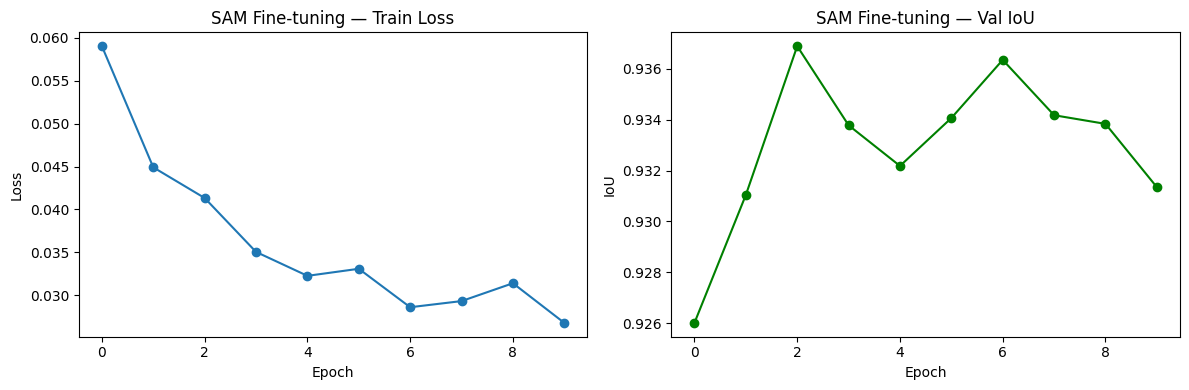

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(sam_history["train_loss"], marker='o')
axes[0].set_title("SAM Fine-tuning — Train Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")

axes[1].plot(sam_history["val_iou"], marker='o', color='green')
axes[1].set_title("SAM Fine-tuning — Val IoU")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("IoU")

plt.tight_layout()
plt.show()

In [ ]:
sam = sam_model_registry[SAM_MODEL_TYPE](checkpoint=SAM_CHECKPOINT)
state = torch.load(SAM_FINETUNED, map_location=device)
sam.load_state_dict(state)
sam.to(device)
sam.eval()

predictor = SamPredictor(sam)
print("Fine-tuned SAM loaded.")

Fine-tuned SAM loaded.


In [ ]:
VALID_EXTS = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}

plantvillage_paths = []
for root, _, files in os.walk(IMAGE_ROOT):
    for f in files:
        if os.path.splitext(f)[1] in VALID_EXTS:
            plantvillage_paths.append(os.path.join(root, f))

plantvillage_paths = sorted(plantvillage_paths)
print(f"PlantVillage images found: {len(plantvillage_paths)}")


def load_plantvillage_image(idx: int) -> np.ndarray:
    path  = plantvillage_paths[idx]
    image = cv2.imread(path)
    if image is None:
        raise FileNotFoundError(f"Could not read: {path}")
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

PlantVillage images found: 20638


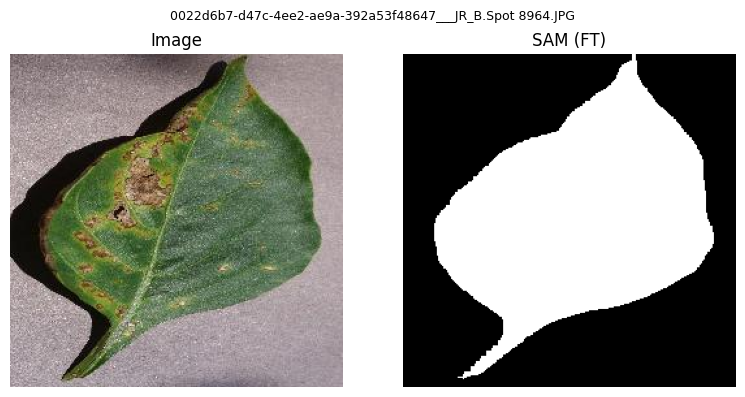

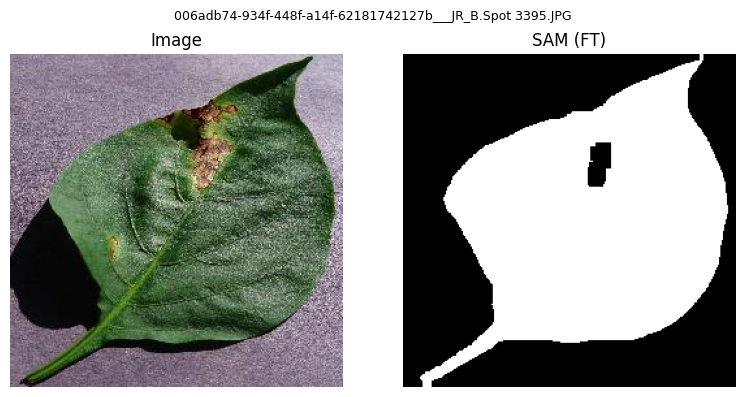

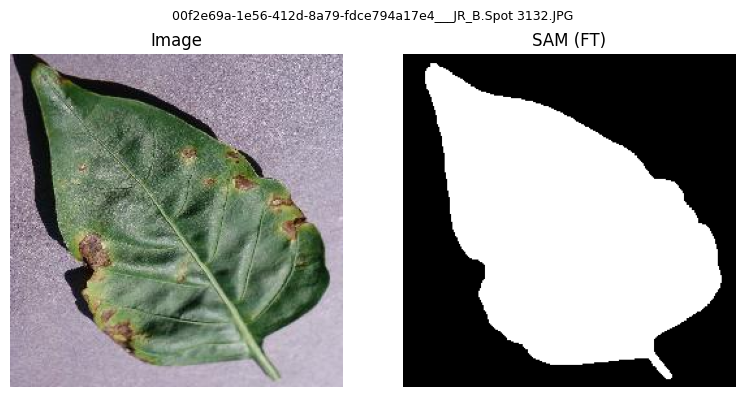

In [ ]:
def get_leaf_mask(image: np.ndarray) -> np.ndarray:
    """
    Segments the leaf in `image` using the fine-tuned SAM predictor.
    Uses a box prompt (full image, slightly inset) plus 5 centre-biased
    point prompts — no GT mask needed at inference time.
    """
    predictor.set_image(image)
    h, w = image.shape[:2]

    # Box prompt: full image slightly inset
    box = np.array([5, 5, w - 5, h - 5])

    # 5 centre-biased point prompts
    pts = np.array([
        [w // 2, h // 2],
        [w // 3, h // 2],
        [2 * w // 3, h // 2],
        [w // 2, h // 3],
        [w // 2, 2 * h // 3],
    ])
    labels = np.ones(len(pts), dtype=np.int32)

    masks, _, _ = predictor.predict(
        point_coords=pts,
        point_labels=labels,
        box=box,
        multimask_output=False,
    )

    mask = masks[0].astype(np.uint8)

    # Morphological cleanup
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((9, 9), np.uint8))

    # Keep only the largest connected component
    num_labels, labels_cc, stats, _ = cv2.connectedComponentsWithStats(mask)
    if num_labels > 1:
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        mask    = (labels_cc == largest).astype(np.uint8)

    return mask


# Quick sanity check on a few PlantVillage images
for check_idx in range(3):
    img  = load_plantvillage_image(check_idx)
    pred = get_leaf_mask(img)

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1); plt.imshow(img);            plt.title("Image");    plt.axis("off")
    plt.subplot(1, 2, 2); plt.imshow(pred, cmap="gray"); plt.title("SAM (FT)"); plt.axis("off")
    plt.suptitle(os.path.basename(plantvillage_paths[check_idx]), fontsize=9)
    plt.tight_layout(); plt.show()

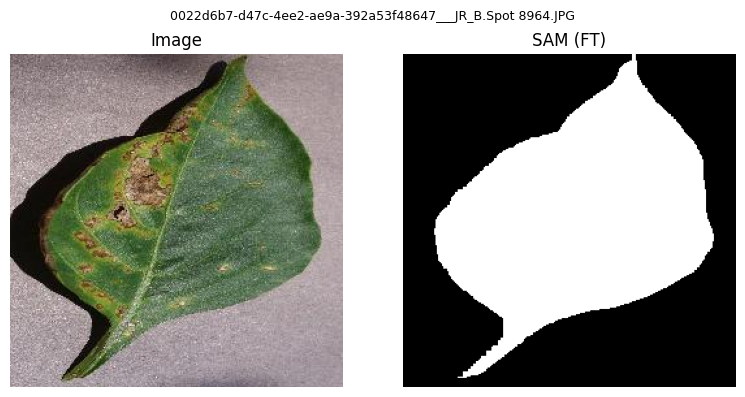

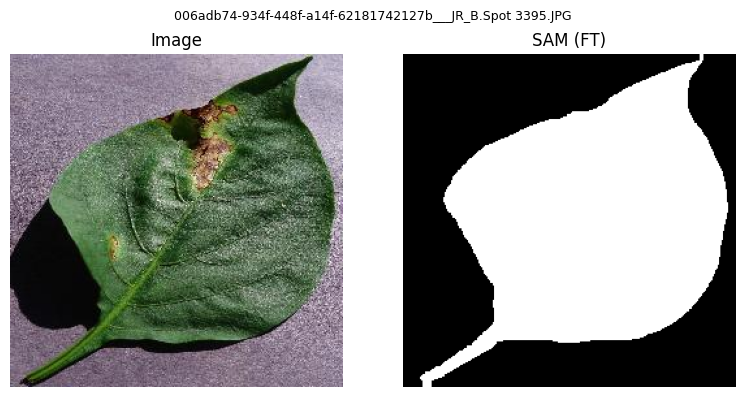

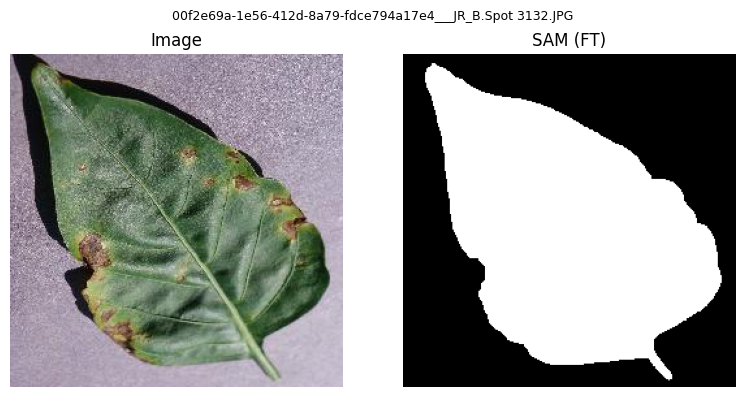

In [ ]:
def detect_lesion_points(image: np.ndarray, n: int = 8) -> np.ndarray:
    """
    Colour-thresholds the image in HSV to find likely diseased pixels
    (brown, yellow-brown, necrotic) and returns up to `n` of them as
    (x, y) point prompts.

    These explicit foreground prompts stop SAM from treating visually
    unusual patches as background / holes.
    """
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    h, s, v = hsv[:,:,0], hsv[:,:,1], hsv[:,:,2]

    brown      = (h >=  5) & (h <= 25) & (s > 60) & (v > 40)
    yellow_brn = (h >= 20) & (h <= 35) & (s > 50) & (v > 60)
    necrotic   = (h >=  0) & (h <= 15) & (s > 40) & (v > 20) & (v < 120)

    lesion_map = (brown | yellow_brn | necrotic).astype(np.uint8)
    lesion_map = cv2.morphologyEx(lesion_map, cv2.MORPH_OPEN,
                                  np.ones((5, 5), np.uint8))

    ys, xs = np.where(lesion_map > 0)
    if len(xs) == 0:
        return np.empty((0, 2), dtype=np.int32)

    idx = np.random.choice(len(xs), size=min(n, len(xs)), replace=False)
    return np.stack([xs[idx], ys[idx]], axis=1)


def get_leaf_mask(image: np.ndarray) -> np.ndarray:
    """
    Segments the whole leaf — including diseased areas — using fine-tuned SAM.

    Three-layer defence against lesion exclusion:
      1. Fine-tuned on synthetic-lesion-augmented images (training fix).
      2. Explicit lesion-colour point prompts at inference (prompt fix).
      3. Hole-filling post-process (safety net).
    """
    predictor.set_image(image)
    h, w = image.shape[:2]

    box = np.array([5, 5, w - 5, h - 5])

    # Centre-biased grid points (healthy tissue)
    grid_pts = np.array([
        [w // 2, h // 2],
        [w // 3, h // 2],
        [2 * w // 3, h // 2],
        [w // 2, h // 3],
        [w // 2, 2 * h // 3],
    ])

    # Lesion-colour points (diseased tissue explicitly marked as foreground)
    lesion_pts = detect_lesion_points(image, n=8)

    pts    = np.vstack([grid_pts, lesion_pts]) if len(lesion_pts) > 0 else grid_pts
    labels = np.ones(len(pts), dtype=np.int32)

    masks, _, _ = predictor.predict(
        point_coords=pts,
        point_labels=labels,
        box=box,
        multimask_output=False,
    )

    mask = masks[0].astype(np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((9, 9), np.uint8))

    # Keep largest connected component
    num_labels, labels_cc, stats, _ = cv2.connectedComponentsWithStats(mask)
    if num_labels > 1:
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        mask    = (labels_cc == largest).astype(np.uint8)

    # Fill any enclosed holes the model still missed
    mask = fill_holes(mask)

    return mask


# Quick sanity check
for check_idx in range(3):
    img  = load_plantvillage_image(check_idx)
    pred = get_leaf_mask(img)

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1); plt.imshow(img);               plt.title("Image");    plt.axis("off")
    plt.subplot(1, 2, 2); plt.imshow(pred, cmap="gray"); plt.title("SAM (FT)"); plt.axis("off")
    plt.suptitle(os.path.basename(plantvillage_paths[check_idx]), fontsize=9)
    plt.tight_layout(); plt.show()

In [ ]:
## original loop



# lesion_files = sorted(os.listdir(LESION_IMG_DIR))


# def load_lesion_pair(idx):
#     img_name  = lesion_files[idx]
#     img_path  = os.path.join(LESION_IMG_DIR, img_name)
#     base      = os.path.splitext(img_name)[0]
#     mask_path = None
#     for f in os.listdir(LESION_MASK_DIR):
#         if base in f:
#             mask_path = os.path.join(LESION_MASK_DIR, f)
#             break
#     if mask_path is None:
#         raise FileNotFoundError(f"No mask found for {img_name}")
#     image = cv2.imread(img_path)
#     image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
#     mask  = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
#     mask  = (mask > 0).astype(np.uint8)
#     return image, mask


# class LesionDataset(Dataset):
#     def __init__(self):
#         mask_files         = os.listdir(LESION_MASK_DIR)
#         self.valid_indices = [
#             i for i, img_name in enumerate(lesion_files)
#             if any(os.path.splitext(img_name)[0] in f for f in mask_files)
#         ]

#     def __len__(self):
#         return len(self.valid_indices)

#     def __getitem__(self, idx):
#         img, mask = load_lesion_pair(self.valid_indices[idx])
#         img  = cv2.resize(img,  (IMG_SIZE, IMG_SIZE))
#         mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE),
#                           interpolation=cv2.INTER_NEAREST)
#         img_t  = torch.tensor(img,  dtype=torch.float32).permute(2, 0, 1) / 255.0
#         mask_t = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
#         return img_t, mask_t


# def bce_dice_loss(pred, target, bce_w=0.85, smooth=1e-6):
#     bce  = F.binary_cross_entropy_with_logits(pred, target)
#     prob = torch.sigmoid(pred)
#     inter = (prob * target).sum(dim=(2, 3))
#     denom = prob.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
#     dice  = 1 - ((2 * inter + smooth) / (denom + smooth)).mean()
#     return bce_w * bce + (1 - bce_w) * dice


# model_lesion   = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet",
#                            in_channels=3, classes=1).to(device)
# optimizer_unet = torch.optim.Adam(model_lesion.parameters(), lr=UNET_LR)

# lesion_dataset = LesionDataset()
# lesion_loader  = DataLoader(lesion_dataset, batch_size=UNET_BS,
#                              shuffle=True, num_workers=2, pin_memory=True)

# print(f"Lesion dataset: {len(lesion_dataset)} samples")

# unet_history = {"loss": [], "iou": []}

# for epoch in range(UNET_EPOCHS):
#     model_lesion.train()
#     total_loss = total_iou = 0.0
#     for imgs, masks in lesion_loader:
#         imgs, masks = imgs.to(device), masks.to(device)
#         preds = model_lesion(imgs)
#         loss  = bce_dice_loss(preds, masks)
#         optimizer_unet.zero_grad()
#         loss.backward()
#         optimizer_unet.step()
#         total_loss += loss.item()
#         total_iou  += compute_iou_batch(preds, masks)
#     avg_loss = total_loss / len(lesion_loader)
#     avg_iou  = total_iou  / len(lesion_loader)
#     unet_history["loss"].append(avg_loss)
#     unet_history["iou"].append(avg_iou)
#     print(f"Epoch {epoch+1}/{UNET_EPOCHS} | Loss: {avg_loss:.4f} | IoU: {avg_iou:.4f}")

# torch.save(model_lesion.state_dict(), "lesion_unet_res34.pth")
# print("UNet weights saved.")

In [ ]:
# ---- Discover ALL image/mask pairs from every directory in LESION_DIRS ----
IMG_EXTS = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG", ".bmp", ".BMP"}

def _collect_pairs(img_dir: str, mask_dir: str) -> list:
    """
    Returns a list of (img_path, mask_path) for every image in img_dir
    whose exact stem matches a file in mask_dir.
    Both directories are searched non-recursively since the structure is flat.
    """
    mask_map = {}
    for f in os.listdir(mask_dir):
        stem = os.path.splitext(f)[0]
        mask_map[stem] = os.path.join(mask_dir, f)

    pairs = []
    for f in sorted(os.listdir(img_dir)):
        if os.path.splitext(f)[1] not in IMG_EXTS:
            continue
        stem = os.path.splitext(f)[0]
        if stem in mask_map:
            pairs.append((os.path.join(img_dir, f), mask_map[stem]))
    return pairs

lesion_pairs = []
for img_dir, mask_dir in LESION_DIRS:
    pairs = _collect_pairs(img_dir, mask_dir)
    print(f"  {img_dir}: {len(pairs)} pairs")
    lesion_pairs.extend(pairs)

print(f"Total lesion pairs: {len(lesion_pairs)}")


def load_lesion_pair_by_paths(img_path: str, mask_path: str):
    image = cv2.imread(img_path)
    if image is None:
        raise FileNotFoundError(f"Cannot read image: {img_path}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    mask  = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise FileNotFoundError(f"Cannot read mask: {mask_path}")
    mask  = (mask > 0).astype(np.uint8)
    return image, mask


# Keep load_lesion_pair(idx) for the sanity-check cell below
def load_lesion_pair(idx: int):
    return load_lesion_pair_by_paths(*lesion_pairs[idx])


def augment_lesion(img: np.ndarray, mask: np.ndarray):
    """
    Lesion-safe augmentation. No random cropping — lesion spots are small
    and cropping removes them, giving the model empty positive samples.
    Only flips, rotations, and colour jitter which preserve all lesion pixels.
    """
    # Flips
    if random.random() < 0.5:
        img  = img[:, ::-1].copy()
        mask = mask[:, ::-1].copy()
    if random.random() < 0.3:
        img  = img[::-1].copy()
        mask = mask[::-1].copy()

    # 90° rotations (preserves all content)
    k    = random.randint(0, 3)
    img  = np.rot90(img,  k).copy()
    mask = np.rot90(mask, k).copy()

    # Resize to target (after rotation shape may differ)
    img  = cv2.resize(img,  (IMG_SIZE, IMG_SIZE))
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE),
                      interpolation=cv2.INTER_NEAREST)

    # Brightness / contrast jitter (mild — don't wash out lesion colours)
    alpha = random.uniform(0.85, 1.15)
    beta  = random.randint(-20, 20)
    img   = np.clip(img.astype(np.float32) * alpha + beta, 0, 255).astype(np.uint8)

    # Mild hue / saturation shift
    if random.random() < 0.4:
        hsv         = cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(np.int32)
        hsv[:,:,0]  = (hsv[:,:,0] + random.randint(-10, 10)) % 180
        hsv[:,:,1]  = np.clip(hsv[:,:,1] + random.randint(-25, 25), 0, 255)
        img         = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

    # Mild blur
    if random.random() < 0.2:
        img = cv2.GaussianBlur(img, (3, 3), 0)

    return img, mask


class LesionDataset(Dataset):
    def __init__(self, indices, augment=False):
        self.indices = indices
        self.augment = augment

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img_path, mask_path = lesion_pairs[self.indices[idx]]
        img, mask = load_lesion_pair_by_paths(img_path, mask_path)
        if self.augment:
            img, mask = augment_lesion(img, mask)
        else:
            img  = cv2.resize(img,  (IMG_SIZE, IMG_SIZE))
            mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE),
                              interpolation=cv2.INTER_NEAREST)
        img_t  = torch.tensor(img,  dtype=torch.float32).permute(2, 0, 1) / 255.0
        mask_t = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
        return img_t, mask_t


# ---- Train / val split (80/20, fixed seed for reproducibility) ----
all_indices = list(range(len(lesion_pairs)))
random.seed(42)
random.shuffle(all_indices)
random.seed()

split     = int(0.8 * len(all_indices))
train_idx = all_indices[:split]
val_idx   = all_indices[split:]

train_ds     = LesionDataset(train_idx, augment=True)
val_ds       = LesionDataset(val_idx,   augment=False)
train_loader = DataLoader(train_ds, batch_size=UNET_BS, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=UNET_BS, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Lesion dataset: {len(train_ds)} train / {len(val_ds)} val samples")


def focal_dice_loss(pred, target, alpha=0.75, gamma=2.0,
                    dice_w=0.5, smooth=1e-6):
    """
    Focal loss + Dice loss.

    Focal loss addresses class imbalance better than weighted BCE:
    - It down-weights easy background pixels (where the model is already
      confident) so training focuses on the hard lesion boundary pixels.
    - alpha=0.75 upweights lesion class; gamma=2 focuses on hard examples.
    Dice loss directly optimises the overlap metric we care about.
    """
    prob = torch.sigmoid(pred)

    # Focal loss
    bce_loss  = F.binary_cross_entropy_with_logits(pred, target, reduction='none')
    p_t       = prob * target + (1 - prob) * (1 - target)
    alpha_t   = alpha * target + (1 - alpha) * (1 - target)
    focal     = alpha_t * (1 - p_t) ** gamma * bce_loss
    focal     = focal.mean()

    # Dice loss
    inter = (prob * target).sum(dim=(2, 3))
    denom = prob.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
    dice  = 1 - ((2 * inter + smooth) / (denom + smooth)).mean()

    return (1 - dice_w) * focal + dice_w * dice


# ---- Model: ResNet50 — bigger than ResNet34, right-sized for ~470 samples ----
# UNet++ decoder gives better feature aggregation for small scattered lesions
model_lesion = smp.UnetPlusPlus(
    encoder_name    = "resnet50",
    encoder_weights = "imagenet",
    in_channels     = 3,
    classes         = 1,
    decoder_attention_type = "scse",   # channel + spatial attention in decoder
).to(device)

optimizer_unet = torch.optim.Adam(model_lesion.parameters(), lr=1e-4)

# ReduceLROnPlateau: only drops LR when val IoU stalls — much safer than
# cosine annealing which forces LR down regardless of whether training is done
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_unet, mode='max', factor=0.5, patience=4, min_lr=1e-7
)

EARLY_STOP_PATIENCE = 12
unet_history = {"train_loss": [], "train_iou": [], "val_loss": [], "val_iou": []}
best_val_iou = 0.0
patience_cnt = 0


def mixup_batch(imgs, masks, alpha=0.4):
    """
    Blends pairs of training samples at the image and mask level.
    Forces the model to learn smooth interpolations between examples
    rather than memorising individual samples — strong regulariser
    for small datasets.
    alpha controls blend strength: 0.4 gives mixes in range [0.4, 0.6].
    """
    lam   = np.random.beta(alpha, alpha)
    idx   = torch.randperm(imgs.size(0), device=imgs.device)
    mixed_imgs  = lam * imgs  + (1 - lam) * imgs[idx]
    mixed_masks = lam * masks + (1 - lam) * masks[idx]
    return mixed_imgs, mixed_masks


for epoch in range(UNET_EPOCHS):
    # -- Train --
    model_lesion.train()
    t_loss = t_iou = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        # Apply mixup with 50% probability per batch
        if random.random() < 0.5:
            imgs, masks = mixup_batch(imgs, masks)

        preds = model_lesion(imgs)
        loss  = focal_dice_loss(preds, masks)
        optimizer_unet.zero_grad()
        loss.backward()
        optimizer_unet.step()
        t_loss += loss.item()
        t_iou  += compute_iou_batch(preds, masks)

    # -- Validate --
    model_lesion.eval()
    v_loss = v_iou = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds  = model_lesion(imgs)
            v_loss += focal_dice_loss(preds, masks).item()
            v_iou  += compute_iou_batch(preds, masks)

    avg_tl = t_loss / len(train_loader);  avg_ti = t_iou / len(train_loader)
    avg_vl = v_loss / len(val_loader);    avg_vi = v_iou / len(val_loader)

    unet_history["train_loss"].append(avg_tl)
    unet_history["train_iou"].append(avg_ti)
    unet_history["val_loss"].append(avg_vl)
    unet_history["val_iou"].append(avg_vi)

    scheduler.step(avg_vi)   # feed val IoU — LR drops only when it stalls

    lr_now = optimizer_unet.param_groups[0]["lr"]
    print(f"Epoch {epoch+1}/{UNET_EPOCHS} | "
          f"Train Loss: {avg_tl:.4f} IoU: {avg_ti:.4f} | "
          f"Val Loss: {avg_vl:.4f} IoU: {avg_vi:.4f} | LR: {lr_now:.2e}")

    if avg_vi > best_val_iou:
        best_val_iou = avg_vi
        patience_cnt = 0
        torch.save(model_lesion.state_dict(), "lesion_unet_best.pth")
        print(f"  ✓ Saved best model (Val IoU={best_val_iou:.4f})")
    else:
        patience_cnt += 1
        if patience_cnt >= EARLY_STOP_PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

model_lesion.load_state_dict(torch.load("lesion_unet_best.pth", map_location=device))
print(f"\nTraining complete. Best Val IoU: {best_val_iou:.4f}")

  /content/lesion_data/data/data/images: 588 pairs
  /content/lesion_data/aug_data/aug_data/images: 2940 pairs
Total lesion pairs: 3528
Lesion dataset: 2822 train / 706 val samples
Epoch 1/20 | Train Loss: 0.2550 IoU: 0.5024 | Val Loss: 0.1846 IoU: 0.6166 | LR: 1.00e-04
  ✓ Saved best model (Val IoU=0.6166)
Epoch 2/20 | Train Loss: 0.1919 IoU: 0.5880 | Val Loss: 0.1364 IoU: 0.6996 | LR: 1.00e-04
  ✓ Saved best model (Val IoU=0.6996)
Epoch 3/20 | Train Loss: 0.1694 IoU: 0.6218 | Val Loss: 0.1212 IoU: 0.7102 | LR: 1.00e-04
  ✓ Saved best model (Val IoU=0.7102)
Epoch 4/20 | Train Loss: 0.1574 IoU: 0.6407 | Val Loss: 0.1078 IoU: 0.7442 | LR: 1.00e-04
  ✓ Saved best model (Val IoU=0.7442)
Epoch 5/20 | Train Loss: 0.1488 IoU: 0.6557 | Val Loss: 0.1023 IoU: 0.7480 | LR: 1.00e-04
  ✓ Saved best model (Val IoU=0.7480)
Epoch 6/20 | Train Loss: 0.1445 IoU: 0.6612 | Val Loss: 0.1059 IoU: 0.7424 | LR: 1.00e-04
Epoch 7/20 | Train Loss: 0.1337 IoU: 0.6831 | Val Loss: 0.0924 IoU: 0.7682 | LR: 1.00e-04

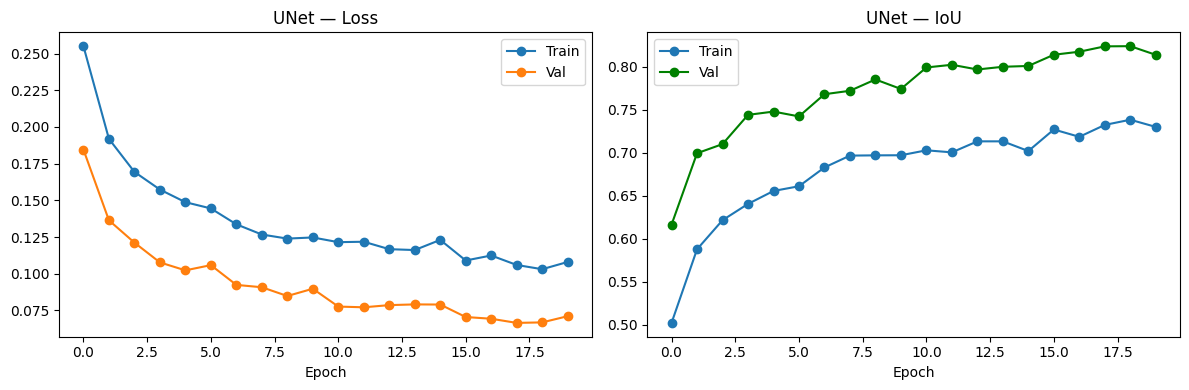

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(unet_history["train_loss"], marker='o', label="Train")
axes[0].plot(unet_history["val_loss"],   marker='o', label="Val")
axes[0].set_title("UNet — Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(unet_history["train_iou"], marker='o', label="Train")
axes[1].plot(unet_history["val_iou"],   marker='o', label="Val", color='green')
axes[1].set_title("UNet — IoU"); axes[1].set_xlabel("Epoch"); axes[1].legend()

plt.tight_layout(); plt.show()

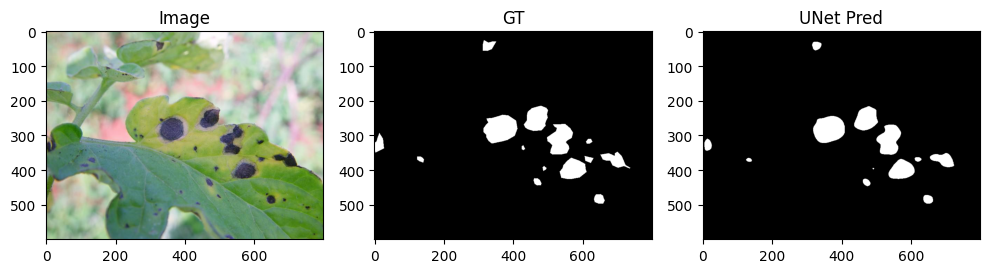

In [ ]:
def get_lesion_mask(image: np.ndarray, threshold: float = 0.40) -> np.ndarray:
    """
    Lesion segmentation with Test-Time Augmentation (TTA).

    Runs inference on 8 versions of the image (original + 3 rotations,
    each with and without horizontal flip), averages the probability maps,
    then thresholds. TTA reduces prediction variance and typically gives
    +2-4 IoU points for free with no retraining.
    """
    model_lesion.eval()

    img_resized = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

    def predict_single(arr: np.ndarray) -> np.ndarray:
        x = torch.tensor(arr, dtype=torch.float32).permute(2, 0, 1) \
                .unsqueeze(0).to(device) / 255.0
        with torch.no_grad():
            logit = model_lesion(x)[0, 0]
        return torch.sigmoid(logit).cpu().numpy()

    prob_sum = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)
    n_augs   = 0

    for k in range(4):                          # 0°, 90°, 180°, 270°
        rotated = np.rot90(img_resized, k).copy()
        prob    = predict_single(rotated)
        prob    = np.rot90(prob, -k).copy()     # undo rotation on probability map
        prob_sum += prob
        n_augs   += 1

        flipped      = rotated[:, ::-1].copy()
        prob_flipped = predict_single(flipped)
        prob_flipped = np.rot90(prob_flipped[:, ::-1], -k).copy()
        prob_sum += prob_flipped
        n_augs   += 1

    avg_prob = prob_sum / n_augs

    # Resize averaged probability map back to original resolution
    avg_prob = cv2.resize(avg_prob, (image.shape[1], image.shape[0]))

    mask = (avg_prob > threshold).astype(np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))
    mask = cv2.erode(mask,                         np.ones((3, 3), np.uint8), iterations=1)
    return mask


# Sanity check
img, gt = load_lesion_pair(5)
pred    = get_lesion_mask(img)

plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1); plt.imshow(img);             plt.title("Image")
plt.subplot(1, 3, 2); plt.imshow(gt,   cmap="gray"); plt.title("GT")
plt.subplot(1, 3, 3); plt.imshow(pred, cmap="gray"); plt.title("UNet Pred")
plt.tight_layout(); plt.show()

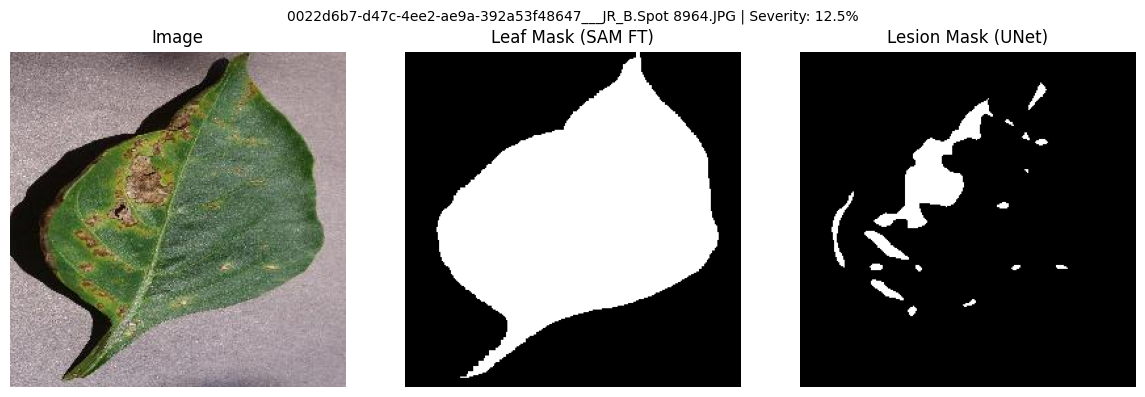

Sample 0 — Severity: 12.53%


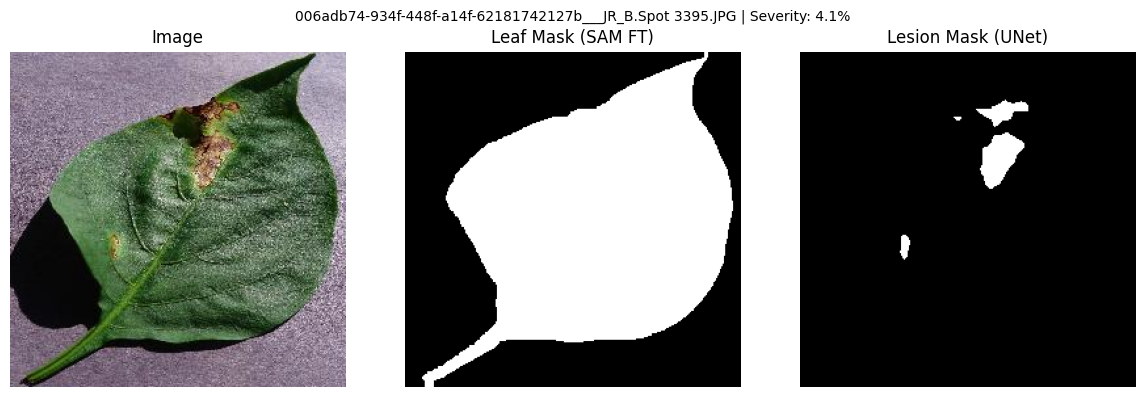

Sample 1 — Severity: 4.07%


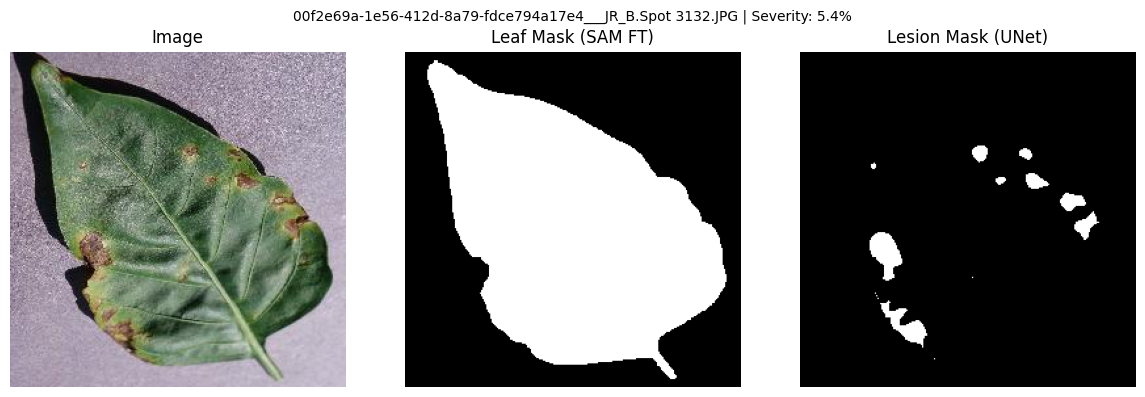

Sample 2 — Severity: 5.45%


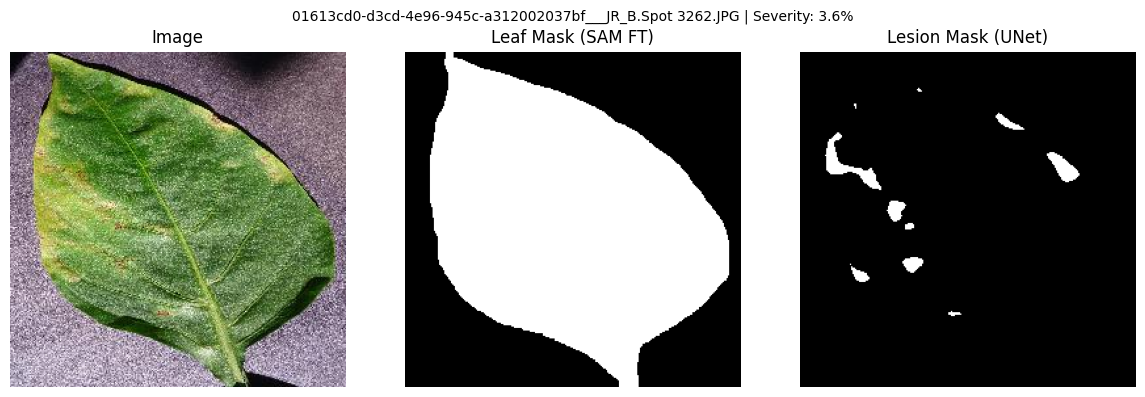

Sample 3 — Severity: 3.61%


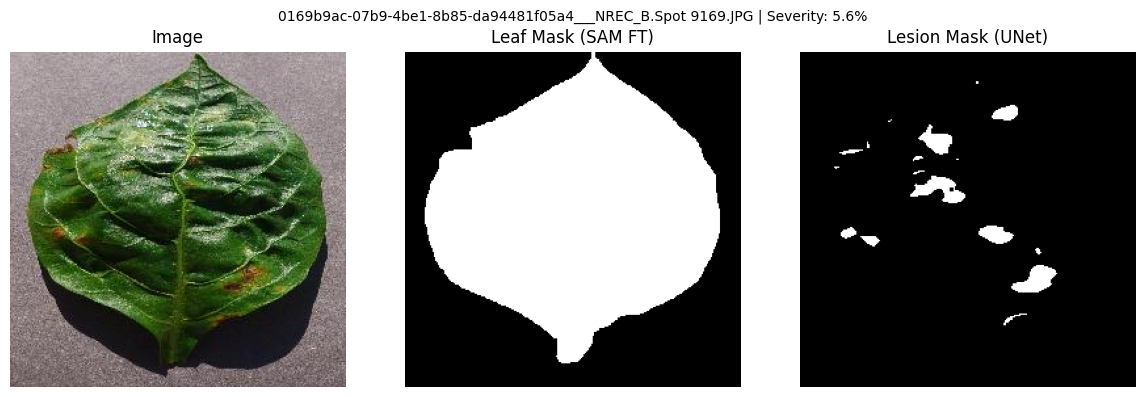

Sample 4 — Severity: 5.64%


In [ ]:
def run_pipeline(idx: int):
    img         = load_plantvillage_image(idx)
    leaf_mask   = get_leaf_mask(img)
    lesion_mask = get_lesion_mask(img)
    lesion_mask = lesion_mask * leaf_mask
    severity    = float(lesion_mask.sum()) / (float(leaf_mask.sum()) + 1e-6)
    return img, leaf_mask, lesion_mask, severity


for sample_idx in range(5):
    img, leaf_pred, lesion_pred, severity = run_pipeline(sample_idx)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img);                         axes[0].set_title("Image")
    axes[1].imshow(leaf_pred,   cmap="gray");    axes[1].set_title("Leaf Mask (SAM FT)")
    axes[2].imshow(lesion_pred, cmap="gray");    axes[2].set_title("Lesion Mask (UNet)")
    for ax in axes: ax.axis("off")
    plt.suptitle(
        f"{os.path.basename(plantvillage_paths[sample_idx])} | "
        f"Severity: {severity*100:.1f}%", fontsize=10)
    plt.tight_layout(); plt.show()
    print(f"Sample {sample_idx} — Severity: {severity*100:.2f}%")

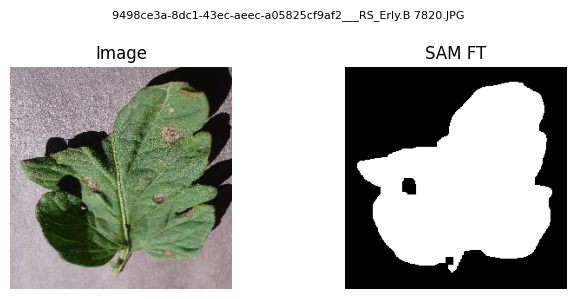

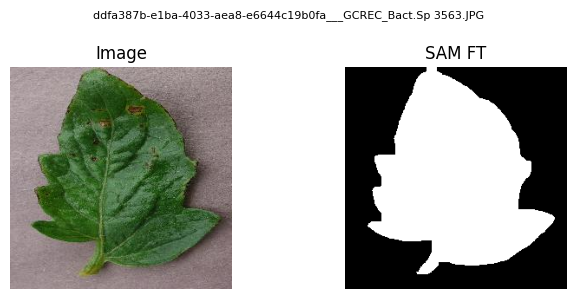

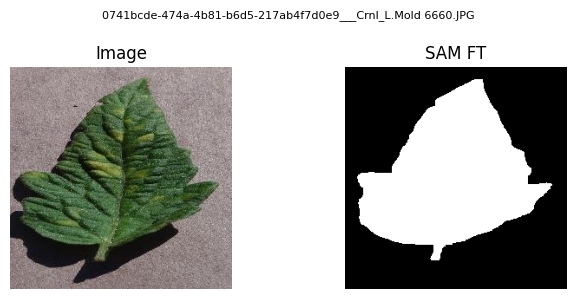

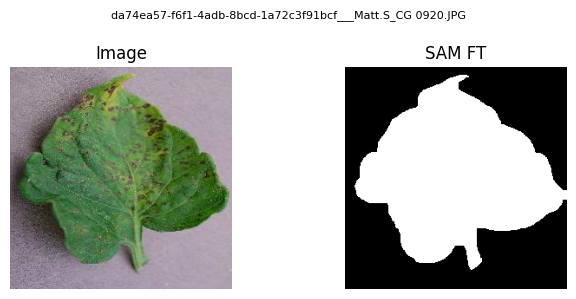

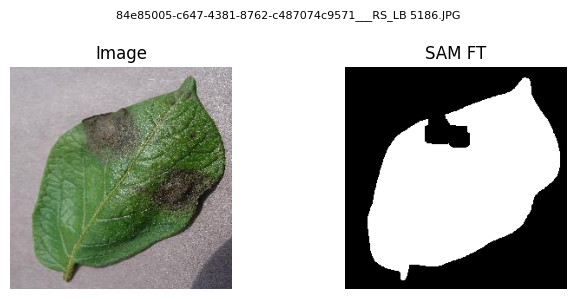

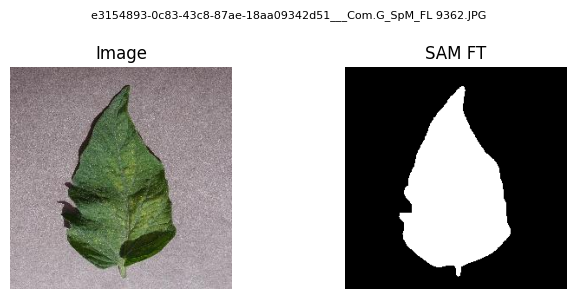

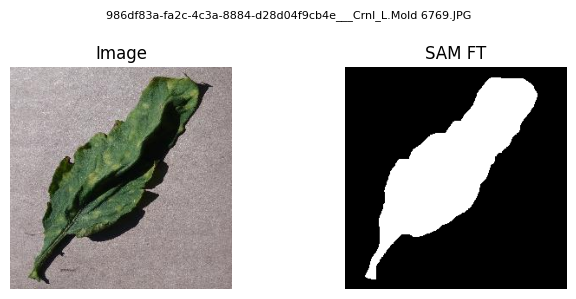

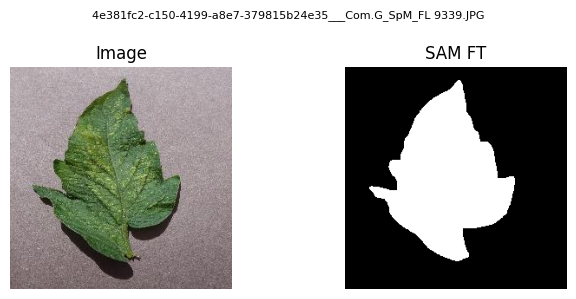

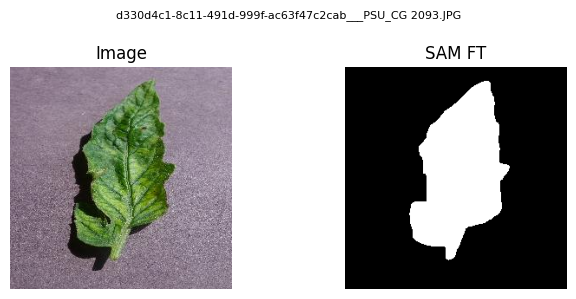

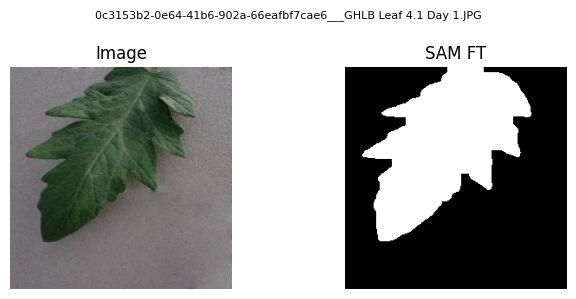

In [ ]:
sample_indices = random.sample(range(len(plantvillage_paths)),
                               min(10, len(plantvillage_paths)))

for i in sample_indices:
    img  = load_plantvillage_image(i)
    pred = get_leaf_mask(img)
    plt.figure(figsize=(7, 3))
    plt.subplot(1, 2, 1); plt.imshow(img);               plt.title("Image");   plt.axis("off")
    plt.subplot(1, 2, 2); plt.imshow(pred, cmap="gray"); plt.title("SAM FT"); plt.axis("off")
    plt.suptitle(os.path.basename(plantvillage_paths[i]), fontsize=8)
    plt.tight_layout(); plt.show()

In [ ]:
lesion_ious  = []
lesion_dices = []

for i in range(len(val_ds)):
    img, gt = load_lesion_pair(val_idx[i])
    pred    = get_lesion_mask(img)
    lesion_ious.append(compute_iou(pred, gt))
    lesion_dices.append(compute_dice(pred, gt))

print(f"Lesion Segmentation (UNet) — evaluated on held-out val set")
print(f"  Mean IoU  : {np.mean(lesion_ious):.4f}")
print(f"  Mean Dice : {np.mean(lesion_dices):.4f}")


Lesion Segmentation (UNet) — evaluated on held-out val set
  Mean IoU  : 0.8108
  Mean Dice : 0.8904
